In [201]:
import pandas as P

In [202]:
D = P.read_csv ("2022 Match.csv")

In [203]:
print(D.columns)

Index(['ID', 'Year', 'Stage', 'Home Team', 'Away Team'], dtype='object')


In [204]:
print(D.shape)

(64, 5)


In [205]:
print(D.dtypes)

ID            int64
Year          int64
Stage        object
Home Team    object
Away Team    object
dtype: object


In [206]:
from sklearn.preprocessing import LabelEncoder

In [207]:
NV = D.isnull ().sum ()
print(NV)

ID           0
Year         0
Stage        0
Home Team    0
Away Team    0
dtype: int64


In [208]:
DV = D.duplicated ().sum ()
print(DV)

0


In [209]:
LE = LabelEncoder ()

In [210]:
print(D.dtypes)

ID            int64
Year          int64
Stage        object
Home Team    object
Away Team    object
dtype: object


In [211]:
D["Stage"] = LE.fit_transform (D["Stage"])
D["Home Team"] = LE.fit_transform (D["Home Team"])
D["Away Team"] = LE.fit_transform (D["Away Team"])

In [212]:
print(D.dtypes)

ID           int64
Year         int64
Stage        int64
Home Team    int64
Away Team    int64
dtype: object


In [213]:
from sklearn.preprocessing import StandardScaler

In [214]:
S = StandardScaler ()

In [215]:
Scaling = S.fit_transform (D)

In [216]:
import matplotlib.pyplot as PLOT
import seaborn as SEA

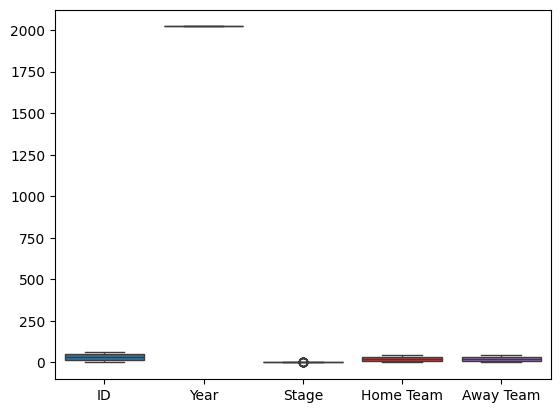

In [217]:
SEA.boxplot (D)
PLOT.show ()

In [218]:
Q1 = D.quantile (0.25)
Q3 = D.quantile (0.75)
IQR = Q3 - Q1
L = Q1 - (1.5 * IQR)
U = Q3 + (1.5 * IQR)
print(Q1)
print(Q3)
print(IQR)
print(L)
print(U)
print("\n")
RO = D[((D >= L).all(axis = 1)) & ((D <= U).all (axis = 1))]
print(RO)

ID             16.75
Year         2022.00
Stage           1.00
Home Team      11.75
Away Team      11.75
Name: 0.25, dtype: float64
ID             48.25
Year         2022.00
Stage           1.00
Home Team      31.25
Away Team      33.00
Name: 0.75, dtype: float64
ID           31.50
Year          0.00
Stage         0.00
Home Team    19.50
Away Team    21.25
dtype: float64
ID            -30.500
Year         2022.000
Stage           1.000
Home Team     -17.500
Away Team     -20.125
dtype: float64
ID             95.500
Year         2022.000
Stage           1.000
Home Team      60.500
Away Team      64.875
dtype: float64


    ID  Year  Stage  Home Team  Away Team
0    1  2022      1         28         16
1    2  2022      1         30         25
2    3  2022      1         16         20
3    4  2022      1         36         44
4    5  2022      1         17          9
5    6  2022      1         14         34
6    7  2022      1         23         26
7    8  2022      1          8        

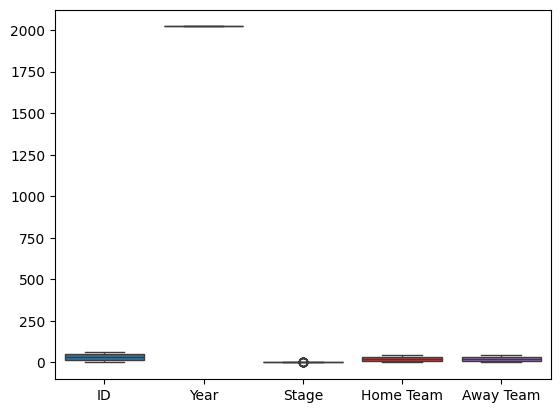

In [219]:
SEA.boxplot(D)
PLOT.show ()

In [220]:
SF = D.to_csv ("2022 FIFA World Cup.csv")